In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import xgboost as xgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import optuna
from optuna.samplers import TPESampler
import pickle

# Import Data

In [2]:
df = pd.read_csv('rome_dataset_features_target_with_focal.csv', low_memory=False)

# Spatial Splitting

In [3]:
"""
Spatial splitting for the Rome UHI / LST project.

Three things are provided:
  1. spatial_block_split    -> single block-based 70/15/15 train/val/test split
                               (the spatial counterpart of your random split, so
                               you can report both side by side)
  2. spatial_block_kfold    -> spatial K-fold CV (GroupKFold on blocks), the more
                               rigorous estimate -> reports mean +/- std across folds
  3. notes at the bottom    -> how to refit the FINAL model on all data for SHAP

Why blocks: every pixel is tagged with the 3 km block it falls in, and whole
blocks are assigned to a single fold. So a test pixel never has a near-identical
neighbour sitting in the training set -- that is what removes the spatial
autocorrelation leakage that inflates the random-split R2.

Assumes a pandas DataFrame `df` with:
  - projected coordinates 'x_utm', 'y_utm' in METRES (EPSG:32633)
  - target column 'LST'
  - the 34 model features (everything except the drop columns below)
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor, early_stopping, log_evaluation


# ----------------------------------------------------------------------
# 0. Configuration  (edit here, not in the functions)
# ----------------------------------------------------------------------
BLOCK_SIZE   = 3000                                  # metres  ->  3 km blocks
TARGET       = "LST"
DROP_COLS    = ["LST", "x_utm", "y_utm", "lon", "lat"]   # non-feature columns
RANDOM_STATE = 42

LGBM_PARAMS = dict(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    verbosity=-1,
)


# ----------------------------------------------------------------------
# 1. Tag every pixel with its spatial block
# ----------------------------------------------------------------------
def add_spatial_blocks(df, block_size=BLOCK_SIZE):
    """Assign each pixel to a (block_size x block_size) cell from its UTM metres."""
    df = df.copy()
    bx = (df["x_utm"] // block_size).astype(int)
    by = (df["y_utm"] // block_size).astype(int)
    df["block_id"] = bx.astype(str) + "_" + by.astype(str)
    return df


def split_xy(frame):
    """Separate features X and target y, dropping coords/target/block_id."""
    drop = [c for c in (DROP_COLS + ["block_id"]) if c in frame.columns]
    X = frame.drop(columns=drop)
    y = frame[TARGET]
    return X, y


def metrics(y_true, y_pred):
    return dict(
        R2=r2_score(y_true, y_pred),
        MAE=mean_absolute_error(y_true, y_pred),
        RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
    )


# ----------------------------------------------------------------------
# 2. Single block-based 70/15/15 split  (parallels your random split)
# ----------------------------------------------------------------------
def spatial_block_split(df, val_frac=0.15, test_frac=0.15, seed=RANDOM_STATE):
    """Assign WHOLE blocks to train/val/test, then gather their pixels."""
    df = add_spatial_blocks(df)
    blocks = np.array(df["block_id"].unique(), dtype=object)

    rng = np.random.default_rng(seed)
    rng.shuffle(blocks)

    n = len(blocks)
    n_test = int(round(test_frac * n))
    n_val  = int(round(val_frac * n))

    test_blocks  = set(blocks[:n_test])
    val_blocks   = set(blocks[n_test:n_test + n_val])
    train_blocks = set(blocks[n_test + n_val:])

    train_df = df[df["block_id"].isin(train_blocks)]
    val_df   = df[df["block_id"].isin(val_blocks)]
    test_df  = df[df["block_id"].isin(test_blocks)]

    print(f"blocks -> train {len(train_blocks)}, val {len(val_blocks)}, test {len(test_blocks)}")
    print(f"pixels -> train {len(train_df)}, val {len(val_df)}, test {len(test_df)}")
    return train_df, val_df, test_df


def run_single_spatial_split(df, params=LGBM_PARAMS):
    """Train on the single spatial split and report honest test metrics."""
    train_df, val_df, test_df = spatial_block_split(df)
    X_train, y_train = split_xy(train_df)
    X_val,   y_val   = split_xy(val_df)
    X_test,  y_test  = split_xy(test_df)

    model = LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="l1",
        callbacks=[early_stopping(50), log_evaluation(200)],
    )

    print("best_iteration:", model.best_iteration_)
    print("SPATIAL split test :", {k: round(v, 3) for k, v in
                                   metrics(y_test, model.predict(X_test)).items()})
    return model, train_df, val_df, test_df


# ----------------------------------------------------------------------
# 3. Spatial K-fold CV  (the rigorous estimate: mean +/- std)
# ----------------------------------------------------------------------
def spatial_block_kfold(df, n_splits=5, params=LGBM_PARAMS):
    """GroupKFold on blocks. Every block is held out exactly once."""
    df = add_spatial_blocks(df)
    X, y = split_xy(df)
    groups = df["block_id"].to_numpy()

    gkf = GroupKFold(n_splits=n_splits)
    fold_rows, best_iters = [], []

    for k, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_te, y_te = X.iloc[te_idx], y.iloc[te_idx]

        # carve a SPATIAL validation set out of the training blocks (for early stopping)
        tr_groups = groups[tr_idx]
        uniq = np.unique(tr_groups)
        rng = np.random.default_rng(RANDOM_STATE + k)
        rng.shuffle(uniq)
        val_blocks = set(uniq[: int(round(0.15 * len(uniq)))])
        is_val = np.isin(tr_groups, list(val_blocks))

        model = LGBMRegressor(**params)
        model.fit(
            X_tr[~is_val], y_tr[~is_val],
            eval_set=[(X_tr[is_val], y_tr[is_val])],
            eval_metric="l1",
            callbacks=[early_stopping(50, verbose=False)],
        )

        m = metrics(y_te, model.predict(X_te))
        fold_rows.append(m)
        best_iters.append(model.best_iteration_ or params["n_estimators"])
        print(f"fold {k}: R2={m['R2']:.3f}  MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  "
              f"(n_test_blocks={len(np.unique(groups[te_idx]))})")

    res = pd.DataFrame(fold_rows)
    print("\nSPATIAL K-fold summary (mean +/- std):")
    for col in res.columns:
        print(f"  {col}: {res[col].mean():.3f} +/- {res[col].std():.3f}")
    print(f"  median best_iteration: {int(np.median(best_iters))}  "
          f"(use this as n_estimators for the final refit)")
    return res, int(np.median(best_iters))


# ----------------------------------------------------------------------
# 4. FINAL model for SHAP  -> refit on ALL data
# ----------------------------------------------------------------------
def fit_final_model(df, n_estimators, params=LGBM_PARAMS):
    """
    The model you actually run SHAP on. Trained on 100% of the pixels, with
    n_estimators fixed to the median best_iteration from the K-fold (no held-out
    set is left to early-stop on, so you cannot let it run all 3000 trees blindly).
    Its credibility comes from the spatial CV above, not from this fit.
    """
    X_all, y_all = split_xy(add_spatial_blocks(df))
    final_params = {**params, "n_estimators": n_estimators}
    model = LGBMRegressor(**final_params).fit(X_all, y_all)
    return model

In [4]:
# ----------------------------------------------------------------------
# 5. Usage
# ----------------------------------------------------------------------

df = pd.read_csv("rome_dataset_features_target_with_focal.csv", low_memory=False)

# (a) single spatial split -> the number you report next to your random 0.87
model_single, df_train, df_val, df_test = run_single_spatial_split(df)

# (b) rigorous spatial estimate -> report this mean +/- std in the write-up
cv_results, best_n = spatial_block_kfold(df, n_splits=5)

# (c) FINAL model for SHAP, refit on all data with the validated tree count
final_model = fit_final_model(df, n_estimators=best_n)
# import shap
# explainer = shap.TreeExplainer(final_model)
# sample = split_xy(add_spatial_blocks(df))[0].sample(50000, random_state=42)
# shap_values = explainer.shap_values(sample)

blocks -> train 58, val 13, test 13
pixels -> train 476717, val 91873, test 109145
Training until validation scores don't improve for 50 rounds
[200]	valid_0's l1: 1.17715	valid_0's l2: 2.30289
[400]	valid_0's l1: 1.16639	valid_0's l2: 2.25899
Early stopping, best iteration is:
[489]	valid_0's l1: 1.16369	valid_0's l2: 2.24908
best_iteration: 489
SPATIAL split test : {'R2': 0.743, 'MAE': 1.16, 'RMSE': 1.487}
fold 1: R2=0.710  MAE=1.201  RMSE=1.576  (n_test_blocks=17)
fold 2: R2=0.704  MAE=1.215  RMSE=1.582  (n_test_blocks=17)
fold 3: R2=0.747  MAE=1.170  RMSE=1.496  (n_test_blocks=17)
fold 4: R2=0.744  MAE=1.077  RMSE=1.379  (n_test_blocks=16)
fold 5: R2=0.763  MAE=1.155  RMSE=1.474  (n_test_blocks=17)

SPATIAL K-fold summary (mean +/- std):
  R2: 0.734 +/- 0.025
  MAE: 1.164 +/- 0.054
  RMSE: 1.501 +/- 0.083
  median best_iteration: 332  (use this as n_estimators for the final refit)


In [5]:
df_train.to_csv("train_spatial_split.csv", index=False)
df_val.to_csv("val_spatial_split.csv", index=False)
df_test.to_csv("test_spatial_split.csv", index=False)

In [5]:
feature_columns = ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio', 'RFDI', 'SAR_urban', 'VV_std', 'VH_std',
                    'texture_contrast', 'NDVI', 'NDBI', 'NDWI', 'Albedo', 'PIS', 'PGS', 'NLI', 'elevation', 'VV_focal',
                      'VH_focal', 'VV_VH_diff_focal', 'VH_VV_ratio_focal', 'RFDI_focal', 'SAR_urban_focal', 'VV_std_focal',
                        'VH_std_focal', 'texture_contrast_focal', 'NDVI_focal', 'NDBI_focal', 'NDWI_focal', 'Albedo_focal', 'PIS_focal', 'PGS_focal', 'NLI_focal', 'elevation_focal']
target_column = 'LST'

In [6]:
print("Features:", feature_columns)
print("Target:", target_column)

Features: ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio', 'RFDI', 'SAR_urban', 'VV_std', 'VH_std', 'texture_contrast', 'NDVI', 'NDBI', 'NDWI', 'Albedo', 'PIS', 'PGS', 'NLI', 'elevation', 'VV_focal', 'VH_focal', 'VV_VH_diff_focal', 'VH_VV_ratio_focal', 'RFDI_focal', 'SAR_urban_focal', 'VV_std_focal', 'VH_std_focal', 'texture_contrast_focal', 'NDVI_focal', 'NDBI_focal', 'NDWI_focal', 'Albedo_focal', 'PIS_focal', 'PGS_focal', 'NLI_focal', 'elevation_focal']
Target: LST


In [ ]:
# metrics for the model trained on the training dataset

# make predictions
pred_train = model_single.predict(df_train[feature_columns])
pred_val = model_single.predict(df_val[feature_columns])
pred_test = model_single.predict(df_test[feature_columns])

# compute R2, MAE, MAPE, RMSE
def compute_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    return r2, mae, mape, np.sqrt(rmse)

train_metrics = compute_metrics(df_train[target_column], pred_train)
val_metrics = compute_metrics(df_val[target_column], pred_val)
test_metrics = compute_metrics(df_test[target_column], pred_test)

print(f"Train Metrics: R2={train_metrics[0]:.2f}, MAE={train_metrics[1]:.4f}, MAPE={train_metrics[2]:.1%}, RMSE={train_metrics[3]:.4f}")
print(f"Validation Metrics: R2={val_metrics[0]:.2f}, MAE={val_metrics[1]:.4f}, MAPE={val_metrics[2]:.1%}, RMSE={val_metrics[3]:.4f}")
print(f"Test Metrics: R2={test_metrics[0]:.2f}, MAE={test_metrics[1]:.4f}, MAPE={test_metrics[2]:.1%}, RMSE={test_metrics[3]:.4f}")

Train Metrics: R2=0.85, MAE=0.8833, MAPE=2.0%, RMSE=1.1287
Validation Metrics: R2=0.69, MAE=1.1637, MAPE=2.6%, RMSE=1.4997
Test Metrics: R2=0.74, MAE=1.1599, MAPE=2.6%, RMSE=1.4875


# Optuna Hyperparameter Tuning

In [8]:
"""
Optuna hyperparameter tuning for the Rome UHI / LST project.

Design principles
-----------------
1. TEST SET IS NEVER TOUCHED.  Tuning runs only on df_train + df_val
   (the ~70+15% that came from run_single_spatial_split).  df_test is
   reserved for the final honest evaluation after tuning.

2. SPATIAL K-FOLD INSIDE TUNING.  Each trial runs GroupKFold (n=5) on the
   train+val data, with whole 3km blocks kept together.  So the search
   never benefits from spatial leakage -- the hyperparameters that win are
   ones that genuinely generalise to unseen blocks.

3. OBJECTIVE PENALISES OVERFITTING.  The objective is not just mean CV R2
   but:
       score = mean_test_R2  -  OVERFIT_PENALTY * mean(train_R2 - test_R2)
   A trial that achieves 0.75 test R2 with a 0.05 gap scores higher than
   one achieving 0.76 test R2 with a 0.15 gap.  OVERFIT_PENALTY controls
   the trade-off; 0.5 is a reasonable starting point.

4. ONLY IMPACTFUL HYPERPARAMETERS ARE TUNED.
   - n_estimators      (number of trees)
   - num_leaves        (tree complexity -- the single biggest lever)
   - min_child_samples (minimum data per leaf -- key regulariser)
   - reg_lambda        (L2 weight penalty)
   - reg_alpha         (L1 weight penalty)
   - subsample         (row subsampling -- variance reducer)
   - colsample_bytree  (feature subsampling -- variance reducer)
   - learning_rate     (paired with early stopping, not n_estimators)

5. TRAIN AND TEST METRICS PER FOLD are logged as Optuna user attributes
   so you can inspect any trial and see the fold-level breakdown.
"""

# import numpy as np
# import pandas as pd
# import optuna
# from optuna.samplers import TPESampler
# from sklearn.model_selection import GroupKFold
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from lightgbm import LGBMRegressor, early_stopping

# from spatial_split import add_spatial_blocks, split_xy, BLOCK_SIZE, RANDOM_STATE

optuna.logging.set_verbosity(optuna.logging.WARNING)   # quiet per-trial noise


# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------
N_TRIALS       = 50      # increase to 100+ for a thorough search
N_CV_FOLDS     = 3
OVERFIT_PENALTY = 0.5    # weight on (train_R2 - test_R2) gap in objective
                          # raise to 0.8-1.0 if you want to prioritise closing
                          # the gap over raw test R2; lower to 0.2 if you
                          # want to prioritise raw test R2

FIXED_PARAMS = dict(
    # n_estimators=1000,    # early stopping will find true optimum
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1,
)


def make_metric(y_true, y_pred):
    return dict(
        R2=r2_score(y_true, y_pred),
        MAE=mean_absolute_error(y_true, y_pred),
        RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
    )


# -----------------------------------------------------------------------
# Core: run one set of hyperparameters through spatial K-fold
# -----------------------------------------------------------------------
def spatial_cv_score(params: dict, df_trainval: pd.DataFrame,
                     n_splits: int = N_CV_FOLDS) -> dict:
    """
    Run spatial K-fold CV and return per-fold and aggregate metrics.

    Returns
    -------
    dict with keys:
        mean_test_R2, std_test_R2
        mean_train_R2, std_train_R2
        mean_gap              (mean train_R2 - test_R2)
        objective             (the penalised score Optuna maximises)
        fold_records          (list of per-fold dicts for logging)
    """
    df = add_spatial_blocks(df_trainval)
    X, y = split_xy(df)
    groups = df["block_id"].to_numpy()

    gkf = GroupKFold(n_splits=n_splits)
    fold_records = []

    for k, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_te, y_te = X.iloc[te_idx], y.iloc[te_idx]

        # # carve a spatial early-stopping set from training blocks
        # tr_groups = groups[tr_idx]
        # uniq_tr = np.unique(tr_groups)
        # rng = np.random.default_rng(RANDOM_STATE + k)
        # rng.shuffle(uniq_tr)
        # es_blocks = set(uniq_tr[: max(1, int(round(0.15 * len(uniq_tr))))])
        # is_es = np.isin(tr_groups, list(es_blocks))

        model = LGBMRegressor(**{**FIXED_PARAMS, **params})
        model.fit(
            X_tr, y_tr,
            # X_tr[~is_es], y_tr[~is_es],
            # eval_set=[(X_tr[is_es], y_tr[is_es])],
            # eval_metric="l1",
            # callbacks=[early_stopping(50, verbose=False)],
        )

        # train_m = make_metric(y_tr[~is_es], model.predict(X_tr[~is_es]))
        train_m = make_metric(y_tr, model.predict(X_tr))
        test_m  = make_metric(y_te,         model.predict(X_te))
        gap     = train_m["R2"] - test_m["R2"]

        fold_records.append(dict(
            fold=k,
            train_R2=train_m["R2"], train_MAE=train_m["MAE"], train_RMSE=train_m["RMSE"],
            test_R2=test_m["R2"],   test_MAE=test_m["MAE"],   test_RMSE=test_m["RMSE"],
            gap=gap,
            # best_iter=model.best_iteration_ or FIXED_PARAMS["n_estimators"],
            best_iter=params["n_estimators"]
        ))

    df_folds = pd.DataFrame(fold_records)
    mean_test  = df_folds["test_R2"].mean()
    std_test   = df_folds["test_R2"].std()
    mean_train = df_folds["train_R2"].mean()
    mean_gap   = df_folds["gap"].mean()
    objective  = mean_test - OVERFIT_PENALTY * mean_gap

    return dict(
        mean_test_R2=mean_test,
        std_test_R2=std_test,
        mean_train_R2=mean_train,
        mean_gap=mean_gap,
        objective=objective,
        fold_records=fold_records,
    )


# -----------------------------------------------------------------------
# Optuna objective
# -----------------------------------------------------------------------
def make_objective(df_trainval: pd.DataFrame):
    def objective(trial: optuna.Trial) -> float:
        params = dict(
            # ---- number of trees ----
            n_estimators=trial.suggest_int("n_estimators", 100, 1500, step=50) ,

            # --- tree structure ---
            num_leaves=trial.suggest_int("num_leaves", 20, 80),

            # --- regularisation (most important for overfitting) ---
            min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
            reg_alpha=trial.suggest_float("reg_alpha",  1e-2, 5.0,  log=True),

            # --- subsampling ---
            subsample=trial.suggest_float("subsample",        0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),

            # --- learning rate ---
            # lower LR + early stopping tends to give a more regularised model
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        )

        result = spatial_cv_score(params, df_trainval)

        # log everything so you can inspect any trial later
        trial.set_user_attr("mean_test_R2",  round(result["mean_test_R2"],  4))
        trial.set_user_attr("std_test_R2",   round(result["std_test_R2"],   4))
        trial.set_user_attr("mean_train_R2", round(result["mean_train_R2"], 4))
        trial.set_user_attr("mean_gap",      round(result["mean_gap"],      4))
        trial.set_user_attr("fold_records",  result["fold_records"])

        return result["objective"]

    return objective


# -----------------------------------------------------------------------
# Main entry: run the search
# -----------------------------------------------------------------------
def run_tuning(df_trainval: pd.DataFrame,
               n_trials: int = N_TRIALS) -> optuna.Study:
    """
    Run the full Optuna search and return the completed study.

    Parameters
    ----------
    df_trainval : concatenation of df_train + df_val from spatial_block_split
    n_trials    : number of Optuna trials (50 quick, 100+ thorough)
    """
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name="lgbm_spatial_uhi",
    )

    print(f"Starting Optuna search: {n_trials} trials, "
          f"{N_CV_FOLDS}-fold spatial CV each, "
          f"overfit_penalty={OVERFIT_PENALTY}")
    print("-" * 65)

    def _callback(study, trial):
        t = trial
        a = t.user_attrs
        print(f"trial {t.number:>3}  "
              f"obj={t.value:.4f}  "
              f"test_R2={a.get('mean_test_R2','?'):.4f}±{a.get('std_test_R2','?'):.4f}  "
              f"train_R2={a.get('mean_train_R2','?'):.4f}  "
              f"gap={a.get('mean_gap','?'):.4f}  "
              f"leaves={t.params.get('num_leaves')}  "
              f"mcs={t.params.get('min_child_samples')}  "
              f"lr={t.params.get('learning_rate'):.4f}  "
              f"n_estimators={t.params.get('n_estimators')}")
        

    # from tqdm.notebook import tqdm

    # progress_bar = tqdm(total=N_TRIALS, desc="Optuna trials")

    # def tqdm_callback(study, trial):
    #     best = study.best_trial
    #     progress_bar.set_postfix({
    #         "best_test_R2": f"{best.user_attrs.get('mean_test_R2', 0):.4f}",
    #         "gap":          f"{best.user_attrs.get('mean_gap', 0):.4f}",
    #         "trial":        best.number,
    #     })
    #     progress_bar.update(1)

    # study.optimize(
    #     make_objective(df_trainval),
    #     n_trials=N_TRIALS,
    #     callbacks=[tqdm_callback],
    # )
    # progress_bar.close()

    study.optimize(make_objective(df_trainval),
                   n_trials=n_trials,
                   callbacks=[_callback],
                   show_progress_bar=True)

    print("\n" + "=" * 65)
    print("BEST TRIAL")
    print("=" * 65)
    best = study.best_trial
    a = best.user_attrs
    print(f"  objective (penalised) : {best.value:.4f}")
    print(f"  mean test  R2         : {a['mean_test_R2']:.4f} ± {a['std_test_R2']:.4f}")
    print(f"  mean train R2         : {a['mean_train_R2']:.4f}")
    print(f"  mean gap              : {a['mean_gap']:.4f}")
    print("  hyperparameters:")
    for k, v in best.params.items():
        print(f"    {k:<22} = {v}")

    print("\nPer-fold breakdown of best trial:")
    for row in a["fold_records"]:
        print(f"  fold {row['fold']}:  "
              f"train_R2={row['train_R2']:.3f}  "
              f"test_R2={row['test_R2']:.3f}  "
              f"gap={row['gap']:.3f}  "
              f"MAE={row['test_MAE']:.3f}  "
              f"best_iter={row['best_iter']}")

    return study


def best_params(study: optuna.Study) -> dict:
    """Return the best params merged with FIXED_PARAMS, ready for LGBMRegressor."""
    return {**FIXED_PARAMS, **study.best_trial.params}


def results_dataframe(study: optuna.Study) -> pd.DataFrame:
    """Return a tidy DataFrame of all trials, useful for plotting."""
    rows = []
    for t in study.trials:
        if t.value is None:
            continue
        row = dict(trial=t.number, objective=t.value)
        row.update(t.params)
        row.update({k: v for k, v in t.user_attrs.items()
                    if k != "fold_records"})
        rows.append(row)
    return pd.DataFrame(rows).sort_values("objective", ascending=False)


In [65]:
# -----------------------------------------------------------------------
# Usage
# -----------------------------------------------------------------------

# df = pd.read_csv("rome_dataset_features_target_with_focal.csv", low_memory=False)

# # hold the test set aside completely -- it is NEVER seen during tuning
# model_single, df_train, df_val, df_test = run_single_spatial_split(df)
df_optim = df_train.sample(n=300_000, random_state=42) # pd.concat([df_train, df_val], ignore_index=True)

# run the search
study = run_tuning(df_optim, n_trials=N_TRIALS)

# inspect all trials
results = results_dataframe(study)
print("\nTop 10 trials:")
display(results.head(10))

Starting Optuna search: 50 trials, 3-fold spatial CV each, overfit_penalty=0.5
-----------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

trial   0  obj=0.6055  test_R2=0.7062±0.0450  train_R2=0.9078  gap=0.2015  leaves=77  mcs=152  lr=0.0735  n_estimators=600
trial   1  obj=0.6471  test_R2=0.7160±0.0435  train_R2=0.8537  gap=0.1377  leaves=63  mcs=23  lr=0.0153  n_estimators=950
trial   2  obj=0.6525  test_R2=0.7138±0.0426  train_R2=0.8365  gap=0.1227  leaves=52  mcs=98  lr=0.0232  n_estimators=500
trial   3  obj=0.6470  test_R2=0.7139±0.0452  train_R2=0.8477  gap=0.1338  leaves=67  mcs=56  lr=0.0148  n_estimators=750
trial   4  obj=0.6612  test_R2=0.7095±0.0476  train_R2=0.8062  gap=0.0967  leaves=77  mcs=194  lr=0.0276  n_estimators=150
trial   5  obj=0.6564  test_R2=0.7116±0.0426  train_R2=0.8220  gap=0.1103  leaves=50  mcs=26  lr=0.0331  n_estimators=250
trial   6  obj=0.6165  test_R2=0.7068±0.0437  train_R2=0.8875  gap=0.1807  leaves=31  mcs=195  lr=0.0835  n_estimators=850
trial   7  obj=0.6662  test_R2=0.7040±0.0469  train_R2=0.7795  gap=0.0755  leaves=31  mcs=28  lr=0.0227  n_estimators=200
trial   8  obj=0.6549

,trial,objective,n_estimators,num_leaves,min_child_samples,reg_lambda,reg_alpha,subsample,colsample_bytree,learning_rate,mean_test_R2,std_test_R2,mean_train_R2,mean_gap
23,23,0.666885,300,24,128,0.038577,0.215988,0.834706,0.875956,0.018795,0.7043,0.0462,0.7790,0.0748
7,7,0.666245,200,31,28,0.094622,0.111951,0.708540,0.931495,0.022738,0.7040,0.0469,0.7795,0.0755
21,21,0.665683,250,26,178,0.101023,0.097099,0.702543,0.962002,0.028697,0.7076,0.0447,0.7915,0.0839
15,15,0.665647,250,22,170,0.158468,0.280091,0.826149,0.798119,0.033445,0.7070,0.0441,0.7898,0.0827
26,26,0.665489,350,29,98,0.044904,0.101668,0.674331,0.967841,0.011380,0.7003,0.0465,0.7700,0.0697
38,38,0.665225,250,36,110,0.072260,0.217400,0.865724,0.823051,0.024610,0.7095,0.0447,0.7981,0.0886
28,28,0.665209,550,24,183,0.477709,0.172073,0.890349,0.857330,0.018096,0.7098,0.0448,0.7991,0.0893
36,36,0.665136,300,24,34,0.032010,0.127763,0.865348,0.923318,0.030801,0.7094,0.0448,0.7979,0.0885
32,32,0.664830,400,20,179,0.218341,0.214760,0.830028,0.905995,0.028244,0.7089,0.0457,0.7970,0.0881
25,25,0.664784,150,38,133,0.010332,0.029928,0.770929,0.884456,0.025941,0.7026,0.0459,0.7781,0.0756


In [71]:
best_params(study)

{'random_state': 42,
 'verbosity': -1,
 'n_jobs': -1,
 'n_estimators': 300,
 'num_leaves': 24,
 'min_child_samples': 128,
 'reg_lambda': 0.03857720932178909,
 'reg_alpha': 0.21598801171228973,
 'subsample': 0.8347063033889262,
 'colsample_bytree': 0.8759561732083417,
 'learning_rate': 0.01879471459020519}

In [75]:
# # train the final tuned model on train+val and evaluate on the held-out test
# from spatial_split import split_xy, add_spatial_blocks
# from lightgbm import LGBMRegressor, early_stopping as es

# X_train = df_train[feature_columns]
# y_train = df_train[target_column]
# X_val = df_val[feature_columns]
# y_val = df_val[target_column]

X_trainval = pd.concat([df_train, df_val], ignore_index=True)[feature_columns]
y_trainval = pd.concat([df_train, df_val], ignore_index=True)[target_column]
X_te = df_test[feature_columns]
y_te = df_test[target_column]

tuned_model = LGBMRegressor(**best_params(study))
tuned_model.fit(
    X_trainval, y_trainval
)

,boosting_type,'gbdt'
,num_leaves,24
,max_depth,-1
,learning_rate,0.01879471459020519
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,128


In [ ]:
# # save model as pickle file
# import pickle
# with open("tuned_lgbm_model_spatial.pkl", "wb") as f:
#     pickle.dump(tuned_model, f)

In [9]:
X_trainval = pd.concat([df_train, df_val], ignore_index=True)[feature_columns]
y_trainval = pd.concat([df_train, df_val], ignore_index=True)[target_column]
X_te = df_test[feature_columns]
y_te = df_test[target_column]

In [10]:
# import model from pickle file

with open("tuned_lgbm_model_spatial.pkl", "rb") as f:
    tuned_model = pickle.load(f)

In [11]:
# make predictions
pred_train = tuned_model.predict(X_trainval)
# pred_val = tuned_model.predict(X_val)
pred_test = tuned_model.predict(X_te)

train_metrics = compute_metrics(y_trainval, pred_train)
# val_metrics = compute_metrics(y_val, pred_val)
test_metrics = compute_metrics(y_te, pred_test)

print(f"Train Metrics: R2={train_metrics[0]:.2f}, MAE={train_metrics[1]:.4f}, MAPE={train_metrics[2]:.1%}, RMSE={train_metrics[3]:.4f}")
# print(f"Validation Metrics: R2={val_metrics[0]:.2f}, MAE={val_metrics[1]:.4f}, MAPE={val_metrics[2]:.1%}, RMSE={val_metrics[3]:.4f}")
print(f"Test Metrics: R2={test_metrics[0]:.2f}, MAE={test_metrics[1]:.4f}, MAPE={test_metrics[2]:.1%}, RMSE={test_metrics[3]:.4f}")

Train Metrics: R2=0.76, MAE=1.1139, MAPE=2.5%, RMSE=1.4305
Test Metrics: R2=0.73, MAE=1.1940, MAPE=2.7%, RMSE=1.5347


In [12]:
df_train.head()

,VV,VH,VV_VH_diff,VH_VV_ratio,RFDI,SAR_urban,VV_std,VH_std,texture_contrast,x_utm,...,texture_contrast_focal,NDVI_focal,NDBI_focal,NDWI_focal,Albedo_focal,PIS_focal,PGS_focal,NLI_focal,elevation_focal,block_id
76,-9.559476,-15.729026,6.169550,0.241571,0.610862,-3.389925,0.767567,0.874523,1.636773,282015.0,...,2.283865,0.418883,0.007969,-0.472473,0.109871,0.162194,0.834233,15.967883,97.112041,94_1551
77,-10.225324,-15.552012,5.326688,0.293313,0.546416,-4.898637,0.710694,1.118756,1.730260,282045.0,...,2.327950,0.441417,-0.006181,-0.488306,0.108455,0.162194,0.834233,16.252283,95.472041,94_1551
78,-10.388510,-16.006628,5.618117,0.274276,0.569518,-4.770393,0.532110,0.611638,1.840261,282075.0,...,2.382320,0.455512,-0.010018,-0.499336,0.108202,0.162194,0.834233,16.536683,94.192041,94_1551
79,-10.285578,-15.624585,5.339006,0.292482,0.547410,-4.946572,0.878664,0.745249,2.052812,282105.0,...,2.439169,0.438131,0.009576,-0.489138,0.111220,0.159352,0.837075,16.821083,93.872041,94_1551
80,-10.087274,-15.716824,5.629550,0.273555,0.570407,-4.457723,0.717154,0.915231,2.219673,282135.0,...,2.482809,0.421787,0.025691,-0.482330,0.114582,0.145518,0.850909,17.105483,95.032041,94_1551


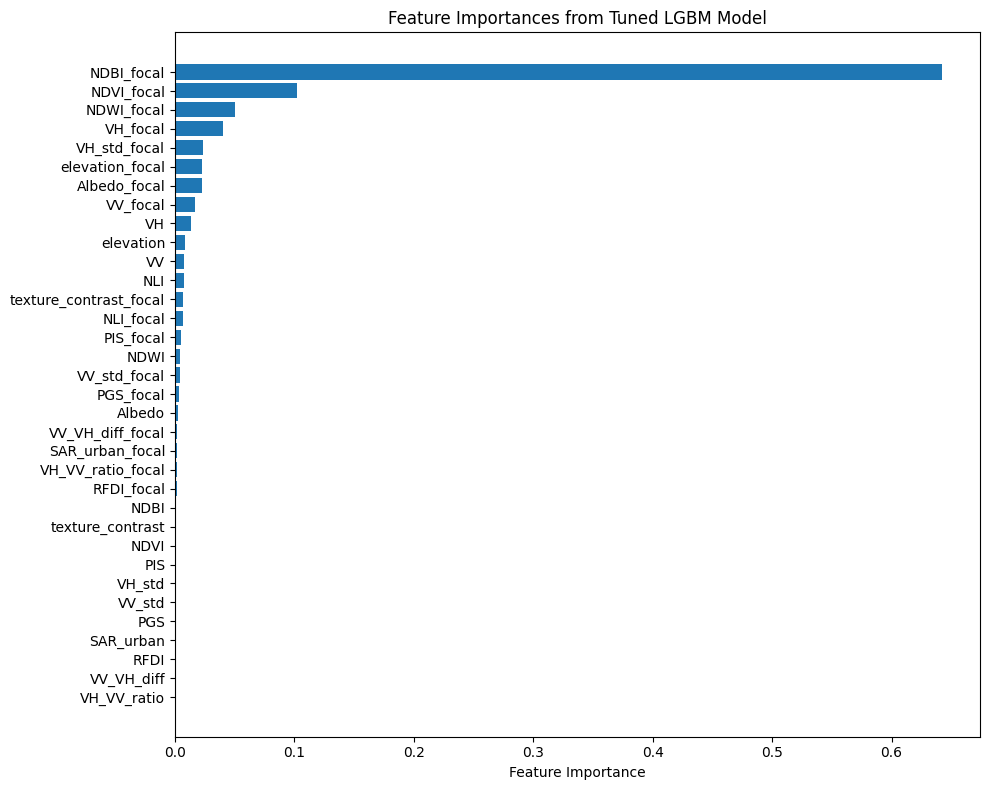

In [13]:
# feature importance plot
import matplotlib.pyplot as plt
importances = tuned_model.booster_.feature_importance(importance_type='gain')
# normalize imporancces to have in total 100%
importances = importances / np.sum(importances)
feature_names = X_trainval.columns
indices = np.argsort(importances)
plt.figure(figsize=(10, 8))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Feature Importances from Tuned LGBM Model')
plt.tight_layout()
# plt.savefig("feature_importance.png", dpi=150)

# Visulizations

In [17]:
"""
Presentation-quality map visualizations for the Rome UHI / LST project.

Figures produced:
  1. aoi_map.png        -- Rome AOI on real basemap (CartoDB Dark Matter)
  2. sentinel1_map.png  -- all 9 SAR features (3×3 grid)
  3. sentinel2_map.png  -- all 7 optical features + elevation (2×4 grid)
  4. lst_map.png        -- Landsat LST map + distribution histogram
  5. split_map.png      -- Spatial train / test block split
                          (val merged into train, as in final pipeline)

Usage:
    from visualize_maps import plot_all
    plot_all(df_train, df_val, df_test)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

import contextily as ctx
from pyproj import Transformer

_to_wm = Transformer.from_crs("EPSG:32633", "EPSG:3857", always_xy=True)

# ── dark presentation palette ────────────────────────────────────────────────
BG    = "#FFFFFF"
AX    = "#F7F9FC"
WHITE = "#111827"
MUTED = "#2563EB"
GRID  = "#D1D9E6"
TICK  = "#374151"

SPLIT_COLORS = {"train": "#2979FF", "test": "#FF1744"}

FEATURE_META = {
    # ── Sentinel-1 ───────────────────────────────────────────────────────────
    "VV":               ("RdBu",      "VV Backscatter (dB)"),
    "VH":               ("RdBu",      "VH Backscatter (dB)"),
    "VV_VH_diff":       ("PuOr",      "VV − VH Difference"),
    "VH_VV_ratio":      ("coolwarm",  "VH/VV Ratio"),
    "RFDI":             ("RdYlGn_r",  "RFDI"),
    "SAR_urban":        ("YlOrRd",    "SAR Urban Index"),
    "VV_std":           ("plasma",    "VV Temporal Std"),
    "VH_std":           ("plasma",    "VH Temporal Std"),
    "texture_contrast": ("magma",     "GLCM Texture Contrast"),
    # ── Sentinel-2 ───────────────────────────────────────────────────────────
    "NDVI":             ("RdYlGn",    "NDVI"),
    "NDBI":             ("RdYlBu_r",  "NDBI"),
    "NDWI":             ("Blues",     "NDWI"),
    "Albedo":           ("gray",      "Albedo"),
    "PIS":              ("OrRd",      "PIS — Impervious Surface (%)"),
    "PGS":              ("YlGn",      "PGS — Green Space (%)"),
    "NLI":              ("hot",       "NLI — Night Light Index"),
    # ── Elevation ────────────────────────────────────────────────────────────
    "elevation":        ("terrain",   "SRTM Elevation (m)"),
    # ── Target ───────────────────────────────────────────────────────────────
    "LST":              ("RdYlBu_r",  "LST (°C)"),
}


# ── shared helpers ────────────────────────────────────────────────────────────

def _wm(x_utm, y_utm):
    """UTM → Web Mercator."""
    return _to_wm.transform(x_utm, y_utm)

def _style_fig(fig):
    fig.patch.set_facecolor(BG)

def _style_ax(ax, title=""):
    ax.set_facecolor(AX)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID)
    ax.tick_params(colors=TICK, labelsize=7)
    if title:
        ax.set_title(title, color=WHITE, fontsize=9,
                     fontweight="bold", pad=6)

def _scatter(ax, x, y, vals, cmap, s=0.4, alpha=0.7):
    lo, hi = np.nanpercentile(vals, 2), np.nanpercentile(vals, 98)
    return ax.scatter(x, y, c=vals, cmap=cmap, s=s, alpha=alpha,
                      vmin=lo, vmax=hi, rasterized=True, linewidths=0)

def _cbar(fig, sc, ax, label=""):
    cb = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.03)
    cb.set_label(label, color=TICK, fontsize=6)
    cb.ax.yaxis.set_tick_params(color=TICK, labelsize=6)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=TICK)

def _figtitle(fig, title, sub=""):
    fig.text(0.5, 0.97, title, ha="center", va="top",
             color=WHITE, fontsize=13, fontweight="bold")
    if sub:
        fig.text(0.5, 0.935, sub, ha="center", va="top",
                 color=MUTED, fontsize=8, style="italic")

def _save(fig, path, dpi=180):
    fig.savefig(path, dpi=dpi, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"saved  {path}")


def _feature_ax(fig, ax, x_wm, y_wm, vals, feat):
    """Plot one feature on an axis that already has a basemap extent."""
    cmap, label = FEATURE_META[feat]
    sc = _scatter(ax, x_wm, y_wm, vals, cmap, s=0.5, alpha=0.75)
    _cbar(fig, sc, ax, label)
    _style_ax(ax, title=label)
    ax.set_xlim(x_wm.min(), x_wm.max())
    ax.set_ylim(y_wm.min(), y_wm.max())
    try:
        ctx.add_basemap(ax, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        alpha=0.45, zoom="auto")
    except Exception:
        pass
    ax.set_axis_off()


# ── Figure 1 — AOI on real basemap ───────────────────────────────────────────

def plot_aoi(df_all, out="aoi_map.png"):
    """
    AOI map: OpenStreetMap basemap (Mapnik) with just the
    bounding-box outline on top.  No pixel scatter -- the basemap
    itself shows Rome.  Matches the GEE leaflet view.
    """
    from pyproj import Transformer
    _to_wm_local = Transformer.from_crs("EPSG:32633", "EPSG:3857", always_xy=True)

    x_utm = df_all["x_utm"].values
    y_utm = df_all["y_utm"].values
    x_wm, y_wm = _to_wm_local.transform(x_utm, y_utm)

    # add a small margin (5%) around the data extent so Rome isn't clipped
    pad_x = (x_wm.max() - x_wm.min()) * 0.05
    pad_y = (y_wm.max() - y_wm.min()) * 0.05
    x0, x1 = x_wm.min() - pad_x, x_wm.max() + pad_x
    y0, y1 = y_wm.min() - pad_y, y_wm.max() + pad_y

    fig, ax = plt.subplots(figsize=(9, 9))
    fig.patch.set_facecolor("#FFFFFF")
    ax.set_facecolor("#FFFFFF")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    # OpenStreetMap Mapnik -- the same tile style as the GEE screenshot
    try:
        ctx.add_basemap(ax, crs="EPSG:3857",
                        source=ctx.providers.OpenStreetMap.Mapnik,
                        zoom="auto")
    except Exception:
        # fallback to Positron if OSM tiles unavailable
        try:
            ctx.add_basemap(ax, crs="EPSG:3857",
                            source=ctx.providers.CartoDB.Positron,
                            zoom="auto")
        except Exception:
            pass

    # AOI bounding box outline (red, matching the GEE style)
    rect = mpatches.Rectangle(
        (x_wm.min(), y_wm.min()),
        x_wm.max() - x_wm.min(),
        y_wm.max() - y_wm.min(),
        linewidth=2.5, edgecolor="#E53935",
        facecolor="none", linestyle="-", zorder=5,
    )
    ax.add_patch(rect)

    ax.set_axis_off()

    # pixel count annotation bottom-left
    ax.text(0.01, 0.01,
            f"{len(df_all):,} pixels  ·  30 m resolution  ·  EPSG:32633",
            transform=ax.transAxes,
            color="#111827", fontsize=8,
            bbox=dict(facecolor="white", alpha=0.85,
                      edgecolor="#D1D9E6", boxstyle="round,pad=0.4"))

    fig.text(0.5, 0.97, "Area of Interest — Rome, Italy",
             ha="center", va="top",
             color="#111827", fontsize=14, fontweight="bold")
    fig.text(0.5, 0.935,
             "Bounding extent of the 30 m satellite raster mosaic",
             ha="center", va="top",
             color="#2563EB", fontsize=9, style="italic")

    _save(fig, out)



# ── Figure 2 — Sentinel-1 (3 × 3) ───────────────────────────────────────────

def plot_sentinel1(df_all, out="sentinel1_map.png"):
    feats = ["VV", "VH", "VV_VH_diff",
             "VH_VV_ratio", "RFDI", "SAR_urban",
             "VV_std", "VH_std", "texture_contrast"]

    fig = plt.figure(figsize=(18, 15))
    _style_fig(fig)
    gs = GridSpec(3, 3, figure=fig, hspace=0.12, wspace=0.12,
                  top=0.91, bottom=0.03, left=0.02, right=0.98)

    x_wm, y_wm = _wm(df_all["x_utm"].values, df_all["y_utm"].values)

    for i, feat in enumerate(feats):
        ax = fig.add_subplot(gs[i // 3, i % 3])
        _feature_ax(fig, ax, x_wm, y_wm, df_all[feat].values, feat)

    _figtitle(fig, "Sentinel-1 SAR Features (9)",
              "C-band SAR · VV & VH · Lee speckle filtered · 11×11 GLCM · 30 m")
    _save(fig, out)


# ── Figure 3 — Sentinel-2 + Elevation (2 × 4) ───────────────────────────────

def plot_sentinel2(df_all, out="sentinel2_map.png"):
    feats = ["NDVI", "NDBI", "NDWI", "Albedo",
             "PIS",  "PGS",  "NLI",  "elevation"]

    fig = plt.figure(figsize=(22, 11))
    _style_fig(fig)
    gs = GridSpec(2, 4, figure=fig, hspace=0.12, wspace=0.12,
                  top=0.91, bottom=0.03, left=0.02, right=0.98)

    x_wm, y_wm = _wm(df_all["x_utm"].values, df_all["y_utm"].values)

    for i, feat in enumerate(feats):
        ax = fig.add_subplot(gs[i // 4, i % 4])
        _feature_ax(fig, ax, x_wm, y_wm, df_all[feat].values, feat)

    _figtitle(fig,
          "Sentinel-2  (6)  +  VIIRS Night Light  +  SRTM Elevation",
          "Sentinel-2 MSI · SCL cloud masking · VIIRS DNBO · SRTM 30 m")
    _save(fig, out)


# ── Figure 4 — LST (map + histogram) ────────────────────────────────────────

def plot_lst(df_all, out="lst_map.png"):
    fig = plt.figure(figsize=(14, 7))
    _style_fig(fig)
    gs = GridSpec(1, 2, figure=fig, wspace=0.22,
                  left=0.03, right=0.97, top=0.88, bottom=0.06,
                  width_ratios=[2, 1])

    x_wm, y_wm = _wm(df_all["x_utm"].values, df_all["y_utm"].values)
    lst = df_all["LST"].values

    # map
    ax_m = fig.add_subplot(gs[0])
    _feature_ax(fig, ax_m, x_wm, y_wm, lst, "LST")
    ax_m.set_title("Land Surface Temperature (°C)",
                   color=WHITE, fontsize=10, fontweight="bold", pad=6)

    # histogram
    ax_h = fig.add_subplot(gs[1])
    ax_h.set_facecolor(AX)
    for sp in ax_h.spines.values():
        sp.set_edgecolor(GRID)

    n, bins, patches = ax_h.hist(
        lst, bins=60, orientation="horizontal",
        edgecolor="none", alpha=0.9)
    norm = mcolors.Normalize(vmin=bins.min(), vmax=bins.max())
    cmap_lst = plt.get_cmap("RdYlBu_r")
    for patch, left in zip(patches, bins[:-1]):
        patch.set_facecolor(cmap_lst(norm(left)))

    ax_h.set_xlabel("Pixel count", color=TICK, fontsize=8)
    ax_h.set_ylabel("LST (°C)",    color=TICK, fontsize=8)
    ax_h.tick_params(colors=TICK,  labelsize=8)
    ax_h.set_title("Distribution", color=WHITE,
                   fontsize=9, fontweight="bold")

    stats = (f"min  {lst.min():.1f} °C\n"
             f"mean {lst.mean():.1f} °C\n"
             f"max  {lst.max():.1f} °C\n"
             f"std   {lst.std():.1f} °C")
    ax_h.text(0.97, 0.03, stats, transform=ax_h.transAxes,
              ha="right", va="bottom", color=MUTED,
              fontsize=8, family="monospace",
              bbox=dict(facecolor=AX, alpha=0.8,
                        edgecolor=GRID, boxstyle="round,pad=0.4"))

    _figtitle(fig, "Target Variable — Land Surface Temperature",
              "Landsat 8/9 · split-window algorithm · 30 m · Rome, Italy")
    _save(fig, out)


# ── Figure 5 — Spatial train / test split ────────────────────────────────────

def plot_split(df_train, df_val, df_test, block_size=3000, out="split_map.png"):
    # val is merged into train in the final pipeline
    df_tr = pd.concat([df_train, df_val], ignore_index=True)
    df_te = df_test

    fig = plt.figure(figsize=(14, 7))
    _style_fig(fig)
    gs = GridSpec(1, 2, figure=fig, wspace=0.18,
                  left=0.03, right=0.97, top=0.88, bottom=0.06)

    splits = [
        (df_tr, "Train", SPLIT_COLORS["train"]),
        (df_te, "Test",  SPLIT_COLORS["test"]),
    ]

    # ── pixel scatter ──
    ax_px = fig.add_subplot(gs[0])
    ax_px.set_facecolor(AX)

    # basemap first
    x_all = pd.concat([df_tr["x_utm"], df_te["x_utm"]]).values
    y_all = pd.concat([df_tr["y_utm"], df_te["y_utm"]]).values
    x_wm_all, y_wm_all = _wm(x_all, y_all)
    ax_px.set_xlim(x_wm_all.min(), x_wm_all.max())
    ax_px.set_ylim(y_wm_all.min(), y_wm_all.max())
    try:
        ctx.add_basemap(ax_px, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        zoom="auto", alpha=0.6)
    except Exception:
        pass

    rng = np.random.default_rng(42)
    for df, label, color in splits:
        x_wm, y_wm = _wm(df["x_utm"].values, df["y_utm"].values)
        n   = min(40_000, len(df))
        idx = rng.choice(len(df), n, replace=False)
        ax_px.scatter(x_wm[idx], y_wm[idx],
                      s=0.3, alpha=0.5, color=color, rasterized=True,
                      label=f"{label}  ({len(df):,} px)")

    ax_px.set_axis_off()
    ax_px.set_title("Pixel level", color=WHITE, fontsize=9,
                    fontweight="bold", pad=6)
    handles = [mpatches.Patch(color=c, label=l)
               for _, l, c in splits]
    ax_px.legend(handles=handles, loc="lower right",
                 facecolor=AX, edgecolor=GRID,
                 labelcolor=TICK, fontsize=8)

    # ── block choropleth ──
    ax_bl = fig.add_subplot(gs[1])
    ax_bl.set_facecolor(AX)
    ax_bl.set_xlim(x_wm_all.min() - block_size,
                   x_wm_all.max() + block_size)
    ax_bl.set_ylim(y_wm_all.min() - block_size,
                   y_wm_all.max() + block_size)
    try:
        ctx.add_basemap(ax_bl, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        zoom="auto", alpha=0.6)
    except Exception:
        pass

    block_counts = {}
    for df, label, color in splits:
        bx = (df["x_utm"] // block_size).astype(int)
        by = (df["y_utm"] // block_size).astype(int)
        blocks = pd.DataFrame({"bx": bx, "by": by}).drop_duplicates()
        block_counts[label] = len(blocks)
        # convert block corners to Web Mercator
        for _, row in blocks.iterrows():
            corners_x = [row.bx * block_size,
                         (row.bx + 1) * block_size,
                         (row.bx + 1) * block_size,
                         row.bx * block_size]
            corners_y = [row.by * block_size,
                         row.by * block_size,
                         (row.by + 1) * block_size,
                         (row.by + 1) * block_size]
            cx, cy = _wm(np.array(corners_x), np.array(corners_y))
            from matplotlib.patches import Polygon as MplPolygon
            poly = MplPolygon(list(zip(cx, cy)),
                              closed=True,
                              linewidth=0.3, edgecolor=BG,
                              facecolor=color, alpha=0.8)
            ax_bl.add_patch(poly)

    ax_bl.set_axis_off()
    ax_bl.set_title(f"Block level  ({block_size//1000} km × {block_size//1000} km)",
                    color=WHITE, fontsize=9, fontweight="bold", pad=6)
    legend_bl = [
        mpatches.Patch(color=SPLIT_COLORS["train"],
                       label=f"Train  ({block_counts.get('Train', '?')} blocks)"),
        mpatches.Patch(color=SPLIT_COLORS["test"],
                       label=f"Test   ({block_counts.get('Test', '?')} blocks)"),
    ]
    ax_bl.legend(handles=legend_bl, loc="lower right",
                 facecolor=AX, edgecolor=GRID,
                 labelcolor=TICK, fontsize=8)

    _figtitle(fig, "Spatial Block Split — Train / Test",
              "Validation merged into Train · 3 km blocks · no pixel-level leakage")
    _save(fig, out)


# ── Convenience wrapper ───────────────────────────────────────────────────────

def plot_all(df_train, df_val, df_test):
    df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
    print("Rendering figures …")
    plot_aoi(df_all)
    plot_sentinel1(df_all)
    plot_sentinel2(df_all)
    plot_lst(df_all)
    plot_split(df_train, df_val, df_test)
    print("\nAll 5 figures saved.")

In [18]:
# ────────────────────────────────────────────────────────────────────────────

# df = pd.read_csv("rome_dataset_features_target_with_focal.csv", low_memory=False)
# _, df_train, df_val, df_test = run_single_spatial_split(df)
plot_all(df_train, df_val, df_test)

Rendering figures …
saved  aoi_map.png
saved  sentinel1_map.png
saved  sentinel2_map.png
saved  lst_map.png
saved  split_map.png

All 5 figures saved.
